# Анализ датасета

Цель: понять структуру `loan_data.csv`, target, пропуски, распределения и очевидные выбросы.

In [29]:
import hashlib
import json
import platform
import sys
from datetime import datetime
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RANDOM_STATE = 42
ROOT_DIR = Path.cwd()
if ROOT_DIR.name == 'notebooks':
    ROOT_DIR = ROOT_DIR.parent

DATA_PATH = ROOT_DIR / 'data' / 'loan_data.csv'
ARTIFACT_DIR = ROOT_DIR / 'artifacts' / 'analyze'
FIG_DIR = ARTIFACT_DIR / 'figures'
PROFILE_PATH = ARTIFACT_DIR / 'data_profile.json'

for path in [ARTIFACT_DIR, FIG_DIR]:
    path.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 140)
plt.style.use('default')


def file_sha256(path: Path) -> str:
    h = hashlib.sha256()
    with path.open('rb') as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b''):
            h.update(chunk)
    return h.hexdigest()


def load_data():
    df = pd.read_csv(DATA_PATH)
    target = 'loan_status'
    X = df.drop(columns=[target])
    y = df[target].astype(int)
    numeric_features = X.select_dtypes(include=np.number).columns.tolist()
    categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()
    return df, X, y, numeric_features, categorical_features

In [30]:
df, X, y, numeric_features, categorical_features = load_data()
data_hash = file_sha256(DATA_PATH)
print('shape:', df.shape)
print('sha256:', data_hash)
print('numeric:', numeric_features)
print('categorical:', categorical_features)
display(df.head())
display(df.dtypes.rename('dtype').to_frame())

shape: (45000, 14)
sha256: 67cca604cd71cbd605014f721d078d20d44d726d625945591450733535f9868a
numeric: ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']
categorical: ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


,dtype
person_age,float64
person_gender,str
person_education,str
person_income,float64
person_emp_exp,int64
person_home_ownership,str
loan_amnt,float64
loan_intent,str
loan_int_rate,float64
loan_percent_income,float64


In [31]:
target_counts = y.value_counts().sort_index()
target_share = y.value_counts(normalize=True).sort_index()
missing = df.isna().sum()

display(pd.DataFrame({'count': target_counts, 'share': target_share}))
display(pd.DataFrame({'missing_count': missing, 'missing_share': missing / len(df)}))
display(df[numeric_features].describe().T)

,count,share
loan_status,,
0,35000,0.777778
1,10000,0.222222


,missing_count,missing_share
person_age,0,0.0
person_gender,0,0.0
person_education,0,0.0
person_income,0,0.0
person_emp_exp,0,0.0
person_home_ownership,0,0.0
loan_amnt,0,0.0
loan_intent,0,0.0
loan_int_rate,0,0.0
loan_percent_income,0,0.0


,count,mean,std,min,25%,50%,75%,max
person_age,45000.0,27.764178,6.045108,20.00,24.00,26.00,30.00,144.00
person_income,45000.0,80319.053222,80422.498632,8000.00,47204.00,67048.00,95789.25,7200766.00
person_emp_exp,45000.0,5.410333,6.063532,0.00,1.00,4.00,8.00,125.00
loan_amnt,45000.0,9583.157556,6314.886691,500.00,5000.00,8000.00,12237.25,35000.00
loan_int_rate,45000.0,11.006606,2.978808,5.42,8.59,11.01,12.99,20.00
loan_percent_income,45000.0,0.139725,0.087212,0.00,0.07,0.12,0.19,0.66
cb_person_cred_hist_length,45000.0,5.867489,3.879702,2.00,3.00,4.00,8.00,30.00
credit_score,45000.0,632.608756,50.435865,390.00,601.00,640.00,670.00,850.00


In [32]:
outliers = []
for col in numeric_features:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (df[col] < low) | (df[col] > high)
    outliers.append({'feature': col, 'outlier_count': int(mask.sum()), 'outlier_share': float(mask.mean()), 'min': df[col].min(), 'max': df[col].max()})
outliers = pd.DataFrame(outliers).sort_values('outlier_share', ascending=False)
display(outliers)
outliers.to_csv(ARTIFACT_DIR / 'outlier_report.csv', index=False)

,feature,outlier_count,outlier_share,min,max
3,loan_amnt,2348,0.052178,500.00,35000.00
1,person_income,2218,0.049289,8000.00,7200766.00
0,person_age,2188,0.048622,20.00,144.00
2,person_emp_exp,1724,0.038311,0.00,125.00
6,cb_person_cred_hist_length,1366,0.030356,2.00,30.00
5,loan_percent_income,744,0.016533,0.00,0.66
7,credit_score,467,0.010378,390.00,850.00
4,loan_int_rate,124,0.002756,5.42,20.00


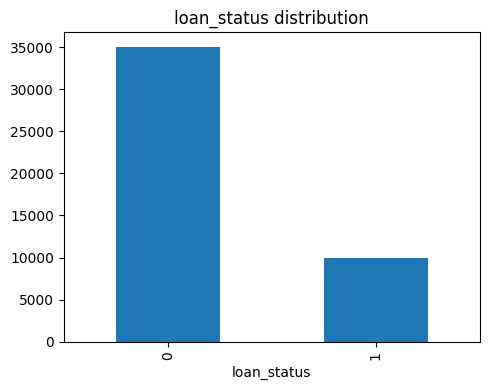

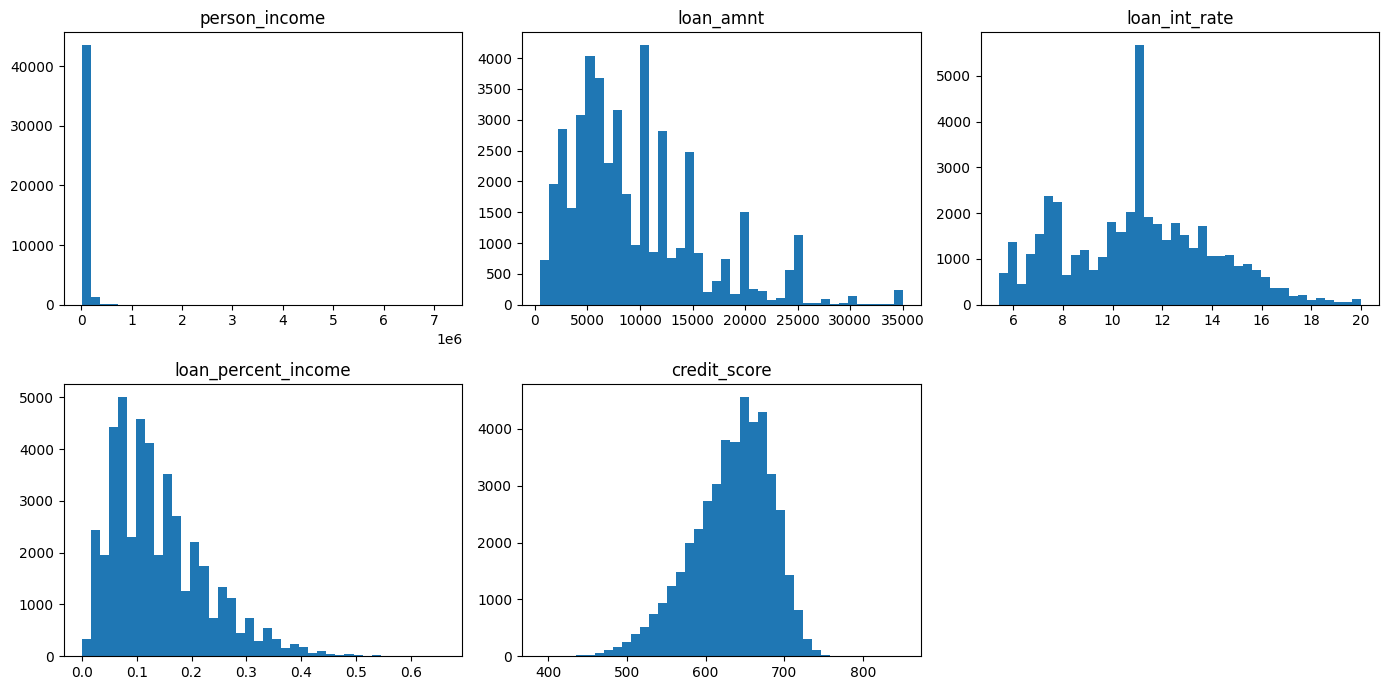

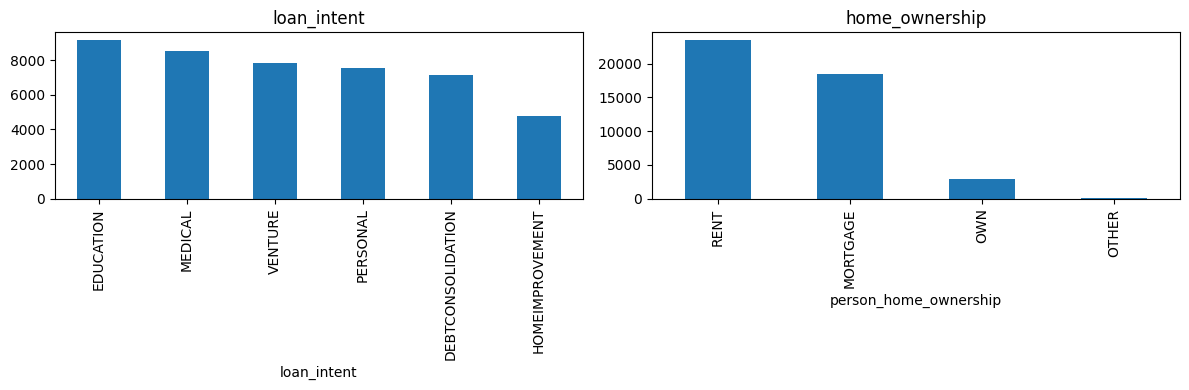

In [33]:
fig, ax = plt.subplots(figsize=(5, 4))
target_counts.plot(kind='bar', ax=ax)
ax.set_title('loan_status distribution')
fig.tight_layout()
fig.savefig(FIG_DIR / 'simple_target_distribution.png', dpi=150)
plt.show()

main_numeric = ['person_income', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'credit_score']
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.ravel()
for ax, col in zip(axes, main_numeric):
    ax.hist(df[col], bins=40)
    ax.set_title(col)
axes[-1].axis('off')
fig.tight_layout()
fig.savefig(FIG_DIR / 'simple_numeric_distributions.png', dpi=150)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['loan_intent'].value_counts().plot(kind='bar', ax=axes[0], title='loan_intent')
df['person_home_ownership'].value_counts().plot(kind='bar', ax=axes[1], title='home_ownership')
fig.tight_layout()
fig.savefig(FIG_DIR / 'simple_categorical_distributions.png', dpi=150)
plt.show()

In [34]:
profile = {
    'data_path': str(DATA_PATH.relative_to(ROOT_DIR)),
    'data_sha256': data_hash,
    'shape': list(df.shape),
    'target': 'loan_status',
    'target_counts': {str(k): int(v) for k, v in target_counts.items()},
    'target_share': {str(k): float(v) for k, v in target_share.items()},
    'missing_total': int(missing.sum()),
    'numeric_features': numeric_features,
    'categorical_features': categorical_features,
    'main_outliers': outliers.head(3)['feature'].tolist(),
}
PROFILE_PATH.write_text(json.dumps(profile, ensure_ascii=False, indent=2), encoding='utf-8')
print(json.dumps(profile, ensure_ascii=False, indent=2))

{
  "data_path": "data/loan_data.csv",
  "data_sha256": "67cca604cd71cbd605014f721d078d20d44d726d625945591450733535f9868a",
  "shape": [
    45000,
    14
  ],
  "target": "loan_status",
  "target_counts": {
    "0": 35000,
    "1": 10000
  },
  "target_share": {
    "0": 0.7777777777777778,
    "1": 0.2222222222222222
  },
  "missing_total": 0,
  "numeric_features": [
    "person_age",
    "person_income",
    "person_emp_exp",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length",
    "credit_score"
  ],
  "categorical_features": [
    "person_gender",
    "person_education",
    "person_home_ownership",
    "loan_intent",
    "previous_loan_defaults_on_file"
  ],
  "main_outliers": [
    "loan_amnt",
    "person_income",
    "person_age"
  ]
}
